# Task 6: Bidirectional LSTM (BiLSTM) Cell from Scratch
Implementation using only PyTorch tensor operations (no nn.LSTM/nn.RNN).

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [2]:
def sigmoid(x):
    return 1/(1+torch.exp(-x))


In [3]:
class LSTMCell:

    def __init__(self,input_size,hidden_size):

        self.input_size=input_size
        self.hidden_size=hidden_size

        def init_gate():
            return (torch.randn(input_size+hidden_size,hidden_size)*0.1,
                    torch.zeros(hidden_size))

        self.Wf,self.bf=init_gate()
        self.Wi,self.bi=init_gate()
        self.Wo,self.bo=init_gate()
        self.Wg,self.bg=init_gate()

    def step(self,x,h,c):

        concat=torch.cat([h,x],dim=1)

        f=sigmoid(concat@self.Wf+self.bf)
        i=sigmoid(concat@self.Wi+self.bi)
        o=sigmoid(concat@self.Wo+self.bo)

        g=torch.tanh(concat@self.Wg+self.bg)

        c=f*c+i*g
        h=o*torch.tanh(c)

        return h,c


In [4]:
class BiLSTM:

    def __init__(self,input_size,hidden_size):

        self.forward_cell=LSTMCell(input_size,hidden_size)
        self.backward_cell=LSTMCell(input_size,hidden_size)

        self.hidden_size=hidden_size

    def forward(self,x,lengths=None):

        batch,seq,input_size=x.shape

        if lengths is None:
            lengths=torch.full((batch,),seq)

        hf=torch.zeros(batch,self.hidden_size)
        cf=torch.zeros(batch,self.hidden_size)

        hb=torch.zeros(batch,self.hidden_size)
        cb=torch.zeros(batch,self.hidden_size)

        forward_outputs=[]

        for t in range(seq):

            mask=(t<lengths).float().unsqueeze(1)

            h_new,c_new=self.forward_cell.step(x[:,t,:],hf,cf)

            hf=mask*h_new+(1-mask)*hf
            cf=mask*c_new+(1-mask)*cf

            forward_outputs.append(hf)

        backward_outputs=[]

        for t in reversed(range(seq)):

            mask=(t<lengths).float().unsqueeze(1)

            h_new,c_new=self.backward_cell.step(x[:,t,:],hb,cb)

            hb=mask*h_new+(1-mask)*hb
            cb=mask*c_new+(1-mask)*cb

            backward_outputs.insert(0,hb)

        output=[]

        for f,b in zip(forward_outputs,backward_outputs):
            output.append(torch.cat([f,b],dim=1))

        return torch.stack(output,dim=1)


In [5]:
batch=4
seq_len=8
input_size=6
hidden_size=10

X=torch.randn(batch,seq_len,input_size)

lengths=torch.tensor([8,7,5,6])

model=BiLSTM(input_size,hidden_size)

output=model.forward(X,lengths)

print("Input Shape :",X.shape)
print("Output Shape:",output.shape)


Input Shape : torch.Size([4, 8, 6])
Output Shape: torch.Size([4, 8, 20])


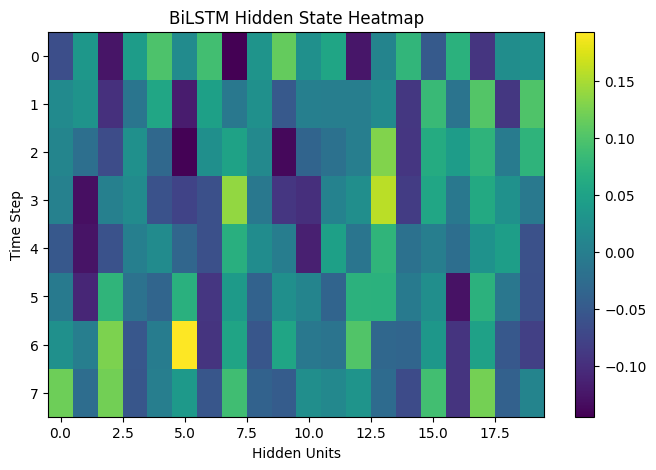

In [6]:
plt.figure(figsize=(8,5))
plt.imshow(output[0].detach().numpy(),aspect='auto',cmap='viridis')
plt.xlabel("Hidden Units")
plt.ylabel("Time Step")
plt.title("BiLSTM Hidden State Heatmap")
plt.colorbar()
plt.show()
